In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

In [2]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "sms_spam_collection.zip"

url = (
    "https://archive.ics.uci.edu/static/public/"
    "228/sms+spam+collection.zip"
)

if not zip_path.exists():
    urlretrieve(url, zip_path)
    print("Dataset downloaded successfully!")
else:
    print("Dataset already exists!")

Dataset downloaded successfully!


In [3]:
extract_dir = data_dir / "sms_spam_collection"

extract_dir.mkdir(exist_ok=True)

with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
for file in extract_dir.rglob("*"):
    if file.is_file():
        print(file)

data\sms_spam_collection\readme
data\sms_spam_collection\SMSSpamCollection


In [5]:
file_path = next(
    extract_dir.rglob("SMSSpamCollection")
)

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.shape

(5572, 2)

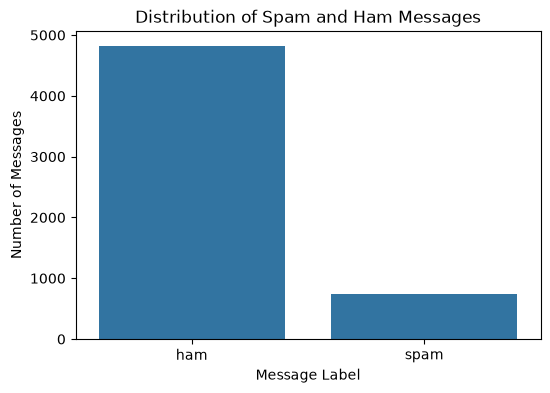

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Label")
plt.ylabel("Number of Messages")

plt.show()

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df["message"].nunique()

5169

In [10]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [13]:
df.drop_duplicates().reset_index(drop=True)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5164,spam,This is the 2nd time we have tried 2 contact u...
5165,ham,Will ü b going to esplanade fr home?
5166,ham,"Pity, * was in mood for that. So...any other s..."
5167,ham,The guy did some bitching but I acted like i'd...


In [14]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [15]:
label_percentage = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_percentage)

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


In [16]:
df["message_length"] = df["message"].str.len()

df[["label", "message", "message_length"]].head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
df.groupby("label")["message_length"].mean()

label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64

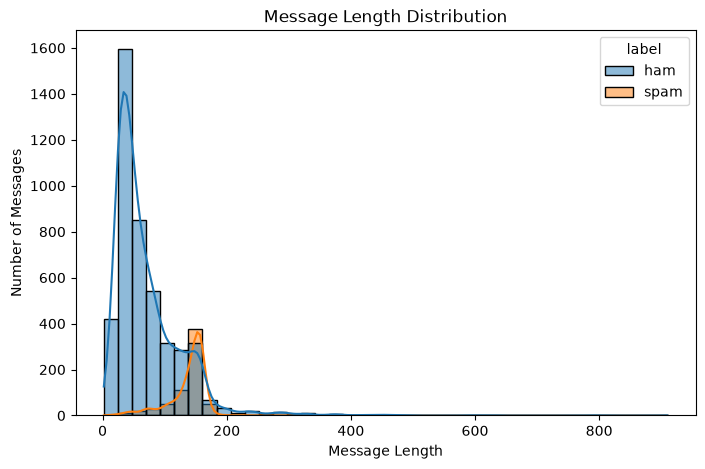

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Number of Messages")

plt.show()

In [19]:
df.sort_values(
    by="message_length",
    ascending=False
)[["label", "message", "message_length"]].head(10)

,label,message,message_length
1060,ham,For me the love should start with attraction.i...,910
1801,ham,The last thing i ever wanted to do was hurt yo...,790
2334,ham,Indians r poor but India is not a poor country...,629
1529,ham,How to Make a girl Happy? It's not at all diff...,611
2076,ham,Sad story of a Man - Last week was my b'day. M...,588
2282,ham,"Good evening Sir, hope you are having a nice d...",482
2865,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461
1464,ham,"Hey sweet, I was wondering when you had a mome...",458
2272,ham,A Boy loved a gal. He propsd bt she didnt mind...,446
2309,ham,Solve d Case : A Man Was Found Murdered On &l...,444


In [20]:
df["word_count"] = df["message"].str.split().str.len()

df[["label", "message", "word_count"]].head()

,label,message,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [21]:
df.groupby("label")["word_count"].mean()

label
ham     14.239814
spam    23.739663
Name: word_count, dtype: float64

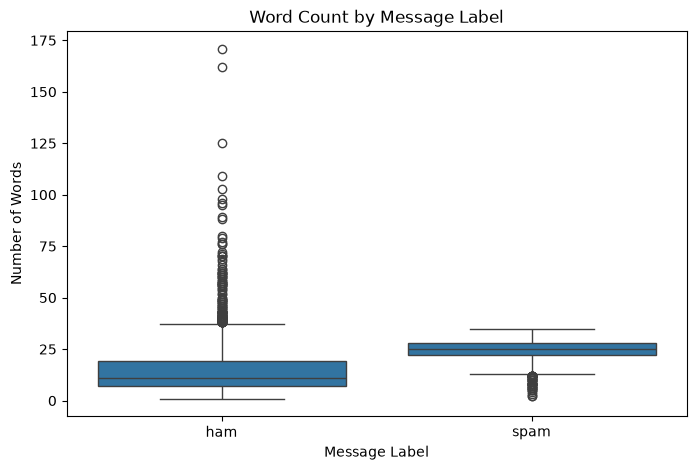

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count by Message Label")
plt.xlabel("Message Label")
plt.ylabel("Number of Words")

plt.show()

In [23]:
df.head()

,label,message,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           5169 non-null   object
 1   message         5169 non-null   object
 2   message_length  5169 non-null   int64 
 3   word_count      5169 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [25]:
output_path = data_dir / "sms_spam_eda.csv"

df.to_csv(output_path, index=False)

print(f"Saved dataset to: {output_path}")

Saved dataset to: data\sms_spam_eda.csv
